# 1.4.4 Smoothing Images

## Kernel Convolution

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [13]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [14]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [15]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [16]:
img

array([[6, 4, 3, 8, 3, 5, 4, 5, 9, 2, 7, 8],
       [4, 1, 3, 6, 1, 4, 7, 3, 3, 5, 6, 7],
       [5, 7, 6, 0, 0, 9, 7, 2, 5, 6, 3, 6],
       [0, 4, 9, 9, 2, 4, 5, 2, 2, 9, 5, 8],
       [7, 6, 1, 9, 4, 0, 6, 3, 2, 4, 4, 2],
       [3, 7, 8, 8, 4, 4, 4, 9, 8, 8, 9, 4],
       [7, 8, 4, 7, 6, 9, 6, 9, 7, 9, 9, 9],
       [8, 1, 8, 8, 4, 7, 9, 3, 9, 2, 2, 3],
       [5, 0, 9, 0, 6, 1, 0, 2, 9, 6, 2, 7],
       [2, 9, 9, 6, 5, 1, 7, 9, 7, 6, 5, 0],
       [5, 2, 4, 9, 4, 0, 6, 0, 2, 6, 7, 6],
       [9, 4, 7, 6, 6, 9, 8, 5, 5, 1, 0, 0]], dtype=int32)

In [17]:
h,w=img.shape

In [18]:
print(h,w)

12 12


In [19]:
#[*range(-2,3)]

In [20]:
dst = np.zeros((h,w),dtype = int)

In [21]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [22]:
img

array([[6, 4, 3, 8, 3, 5, 4, 5, 9, 2, 7, 8],
       [4, 1, 3, 6, 1, 4, 7, 3, 3, 5, 6, 7],
       [5, 7, 6, 0, 0, 9, 7, 2, 5, 6, 3, 6],
       [0, 4, 9, 9, 2, 4, 5, 2, 2, 9, 5, 8],
       [7, 6, 1, 9, 4, 0, 6, 3, 2, 4, 4, 2],
       [3, 7, 8, 8, 4, 4, 4, 9, 8, 8, 9, 4],
       [7, 8, 4, 7, 6, 9, 6, 9, 7, 9, 9, 9],
       [8, 1, 8, 8, 4, 7, 9, 3, 9, 2, 2, 3],
       [5, 0, 9, 0, 6, 1, 0, 2, 9, 6, 2, 7],
       [2, 9, 9, 6, 5, 1, 7, 9, 7, 6, 5, 0],
       [5, 2, 4, 9, 4, 0, 6, 0, 2, 6, 7, 6],
       [9, 4, 7, 6, 6, 9, 8, 5, 5, 1, 0, 0]], dtype=int32)

In [23]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -14,  -4,  12,  -9,  -6,  10,  -5, -10,   3,   2,   0],
       [  0,  12,   5, -21, -12,  21,   5,  -9,   7,   2, -11,   0],
       [  0,  -6,  16,  16,  -9,   0,   1,  -4, -10,  19,  -4,   0],
       [  0,   5, -28,  14,   1, -18,  12,  -7,  -9,  -7,  -4,   0],
       [  0,   3,  12,   4,  -6,  -1,  -9,  12,   6,   2,  11,   0],
       [  0,  13, -15,   2,   0,  13,  -7,  11,  -7,  10,   7,   0],
       [  0, -20,  10,  13, -11,   5,  20, -17,  15, -18,  -8,   0],
       [  0, -24,  19, -29,  14, -10, -19, -13,  12,   5, -12,   0],
       [  0,  23,   8,   1,   3,  -9,  12,  20,   2,   0,   5,   0],
       [  0, -14, -11,  16,  -4, -20,   9, -22, -10,   8,  11,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [29]:
img = cv2.imread('MAX.jpg', 0)

In [30]:
h,w=img.shape

In [31]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [38]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

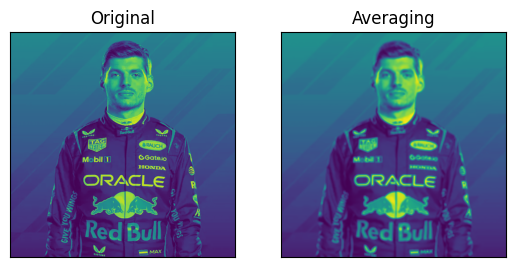

In [40]:
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

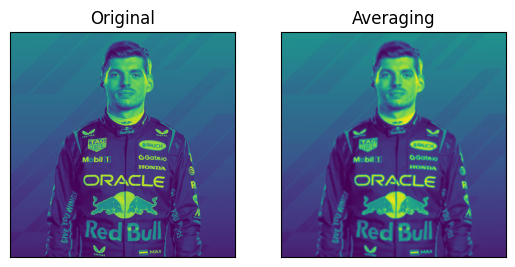

In [48]:
kernel = np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img,(5,5),0)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

In [49]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()